<div style="display: flex; justify-content: space-between; align-items: center;">

<img src="https://github.com/ctapia16/Analisis-y-Visualizacion/blob/main/logoFIME.jpg?raw=true" width="150"/>

<img src="https://github.com/ctapia16/Analisis-y-Visualizacion/blob/main/logo_ICI.png?raw=true" width="200"/>

</div>

<br>

<h2 style="text-align: center;">
Universidad de Colima
</h2>

<h3 style="text-align: center;">
Facultad de Ingeniería Mecánica y Eléctrica
    </h3>

<h3 style="text-align: center;">
Ingeniería en Computación Inteligente
</h3>

<h3 style="text-align: center;">
Data Analysis and Visualization
</h3>

<h2 style="text-align: center;">
Exploratory Analysis of the Wheater History
</h2>

<br>

<p style="text-align: center;">
<strong>Alumnos:</strong> Carlos Isaac Tapia Gonzalez<br>
<strong>Lugar:</strong> Colima, Colima<br>
<strong>Fecha:</strong> February 2026
</p>

### Introduction

### Paso 1  Importar librerias 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# Cargar el dataset 
df = pd.read_excel('commercial_sales.xlsx')

In [5]:
# initial diagnosis
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order Date        100 non-null    datetime64[ns]
 1   Product           100 non-null    object        
 2   Quantity Ordered  100 non-null    int64         
 3   Price Each        100 non-null    int64         
 4   City              100 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 4.0+ KB
None


## Step 2: Data Wrangling (Cleaning and Preparation)

In [6]:
# Convert the 'Order Date' column to a datetime object
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [7]:
# Extract the month name for seasonal analysis
df['Month'] = df['Order Date'].dt.month_name()
# Calculate Total Sales (Quantity * Price)
df['Sales Total'] = df['Quantity Ordered'] * df['Price Each']
print(df[['Order Date', 'Month', 'Sales Total']].head())

  Order Date     Month  Sales Total
0 2025-01-15   January          700
1 2025-02-10  February         4800
2 2025-03-05     March           30
3 2025-04-20     April          100
4 2025-12-20  December          150


## Step 3: Star Product Analysis (Visualization)

/tmp/ipykernel_31159/759656602.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


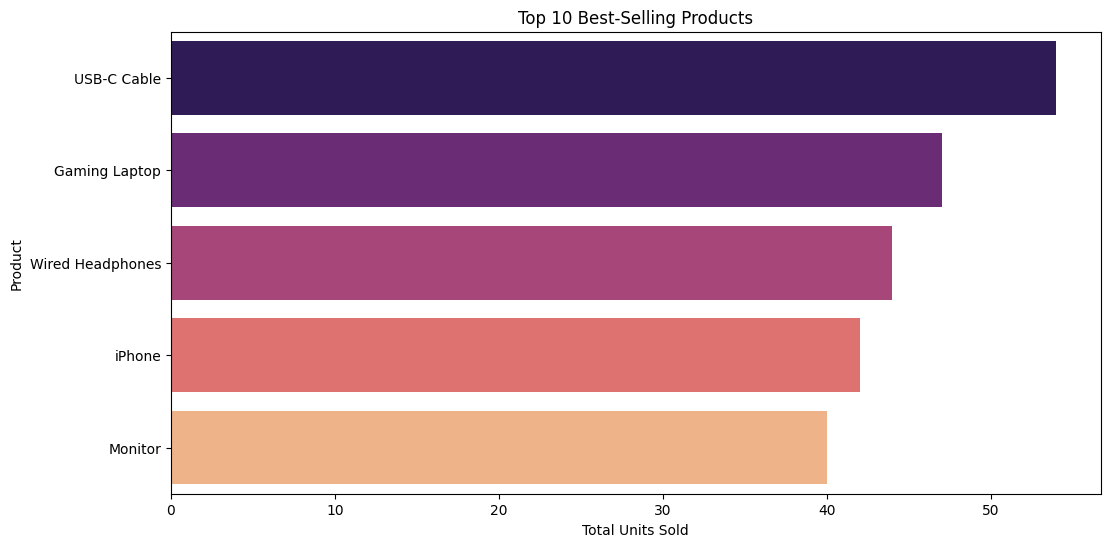

In [8]:
# Group by product and sum the quantities
top_products = df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Units Sold')
plt.show()

## Step 4: Monthly Sales Trends (Seasonality)

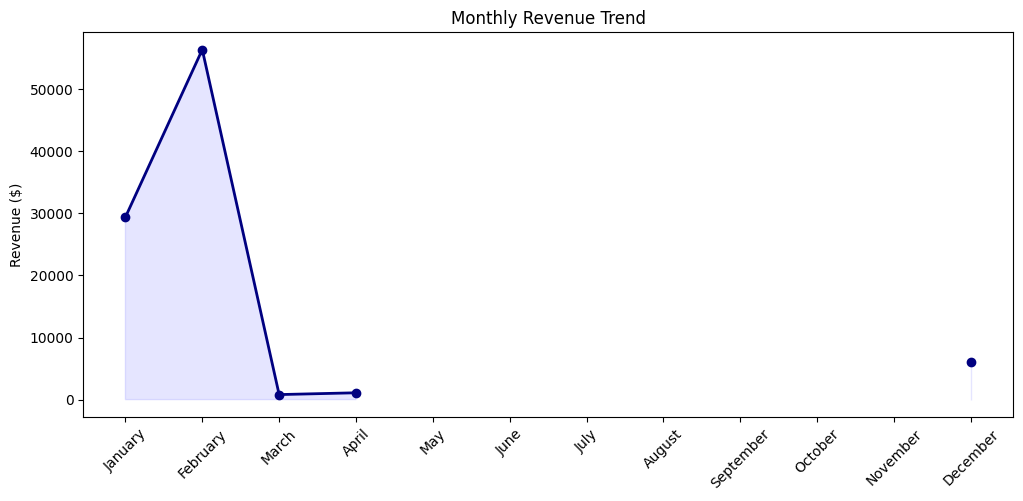

In [9]:
# Order months chronologically instead of alphabetically
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = df.groupby('Month')['Sales Total'].sum().reindex(month_order)
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='navy', linewidth=2)
plt.fill_between(monthly_sales.index, monthly_sales.values, color='blue', alpha=0.1)
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.ylabel('Revenue ($)')
plt.show()

## Average ticket 


In [10]:
average_ticket = df["Sales Total"].mean()
print("Average Ticket (mean Sales Total):", average_ticket)

Average Ticket (mean Sales Total): 937.1


## Revenue por city 

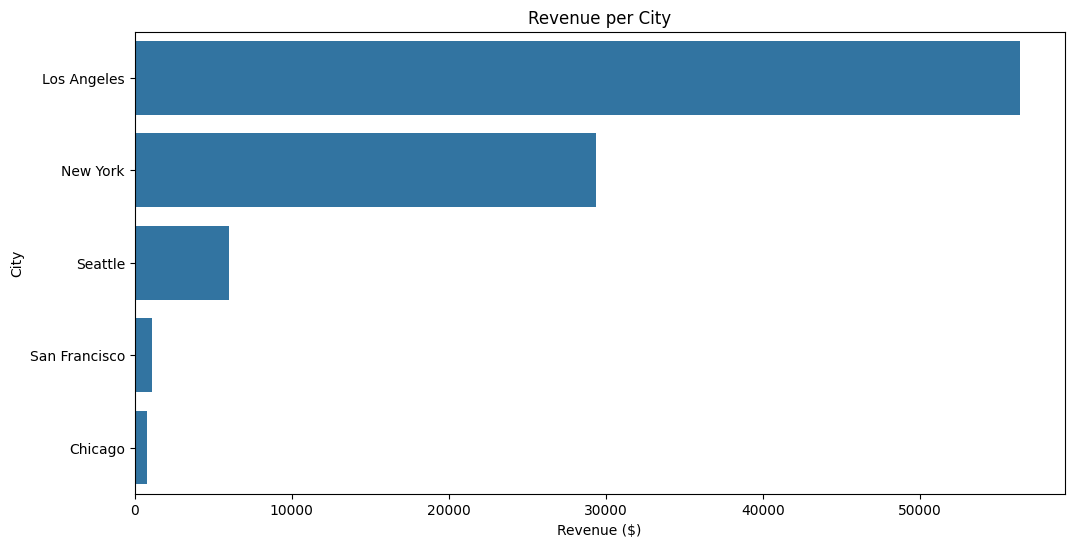

In [11]:
city_revenue = df.groupby("City")["Sales Total"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=city_revenue.values, y=city_revenue.index)
plt.title("Revenue per City")
plt.xlabel("Revenue ($)")
plt.ylabel("City")
plt.show()

## Conclusion

Based on the data, my strategic recommendation for management is to focus on strengthening the sales performance of the best-selling products and optimizing operations during the months with the highest revenue. The analysis shows that certain products contribute significantly more to total revenue, which suggests that increasing their availability, improving their promotion, and ensuring sufficient inventory could maximize profits. Additionally, the monthly trend reveals variations in sales performance, which can help management identify peak and low-demand periods. This information is valuable for planning marketing campaigns, adjusting staffing levels, and managing inventory more efficiently. Furthermore, analyzing revenue by city allows the company to identify its strongest markets and prioritize investment in those locations while developing strategies to improve performance in weaker areas. Overall, the insights obtained from this analysis provide a solid foundation for making data-driven decisions that improve operational efficiency, increase revenue, and support long-term business growth.